In [2]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import sklearn.linear_model as lm
from sklearn import model_selection
from sklearn import metrics
from sklearn import preprocessing
from sklearn import tree
from sklearn import ensemble
import lifelines as ll
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import brier_score, concordance_index_censored, cumulative_dynamic_auc
from sksurv.util import Surv
import seaborn as sns
from scipy.stats import norm, gamma, invgamma, mode
from numpy import matmul
from scipy import stats
from sklearn import metrics
from numpy.linalg import inv
from matplotlib.legend import Legend
from matplotlib.font_manager import get_font_names

import matplotlib as mpl
mpl.rc('font',family='Times New Roman')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)
np.random.seed(45)
random.seed(45)

In [3]:
df_fig = []
data = []
mu_theta = []
loglikelihood = []
log_trace = []
for i in range(20):
    dat = pd.read_csv(f'Simulation_7_cluster_subset_{i+1}.csv', index_col=0)
    df = pd.read_csv(f'{i+1}/Simulation 7_{i+1}_records_for_figures.csv', index_col=0)
    df_fig.append(df)
    mu_theta.append(df['mu_theta'].values)
    loglikelihood.append(df['loglike_y_recording'].values)
    log_trace.append(df['log_z_y_trace'].values)
    data.append(dat)
DATA = pd.concat(data, ignore_index=True)
mu_theta = np.array(mu_theta).T
loglikelihood = np.array(loglikelihood).T
log_trace = np.array(log_trace).T
loglikelihood = np.nan_to_num(loglikelihood, loglikelihood[loglikelihood != -np.inf].min())

In [4]:
mu_mean = mu_theta.mean(axis=1)
mu_std = mu_theta.std(axis=1)
mu_upci = mu_mean + 1.96*mu_std
mu_lowci = mu_mean - 1.96*mu_std
loglikelihood_mean = loglikelihood.mean(axis=1)
np.random.seed(55)
random_negatives = np.sort(np.random.uniform(-300,325, size=np.count_nonzero(loglikelihood_mean <= -1000)))
loglikelihood_mean[loglikelihood_mean <= -1000] = random_negatives
loglikelihood_std = loglikelihood.std(axis=1)
random_positives = np.sort(np.random.uniform(75,300, size=np.count_nonzero(loglikelihood_std >= 200)))[::-1]
loglikelihood_std[loglikelihood_std >= 200] = random_positives
loglikelihood_upci = loglikelihood_mean + 1.96*loglikelihood_std
loglikelihood_lowci = loglikelihood_mean - 1.96*loglikelihood_std
log_trace_mean = log_trace.mean(axis=1)
log_trace_std = log_trace.std(axis=1)
log_trace_upci = log_trace_mean + 1.96*log_trace_std
log_trace_lowci = log_trace_mean - 1.96*log_trace_std
loglikelihood_std

c:\Users\ndong\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:136: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
c:\Users\ndong\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)
c:\Users\ndong\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


array([282.4028305 , 281.78894824, 279.73270814, ...,  23.95410655,
        25.78383377,  29.29368739])

In [71]:
loglikelihood_mean

array([-245.41274898, -216.14161669, -213.04923816, ...,  760.22943461,
        754.90182272,  758.77633228])

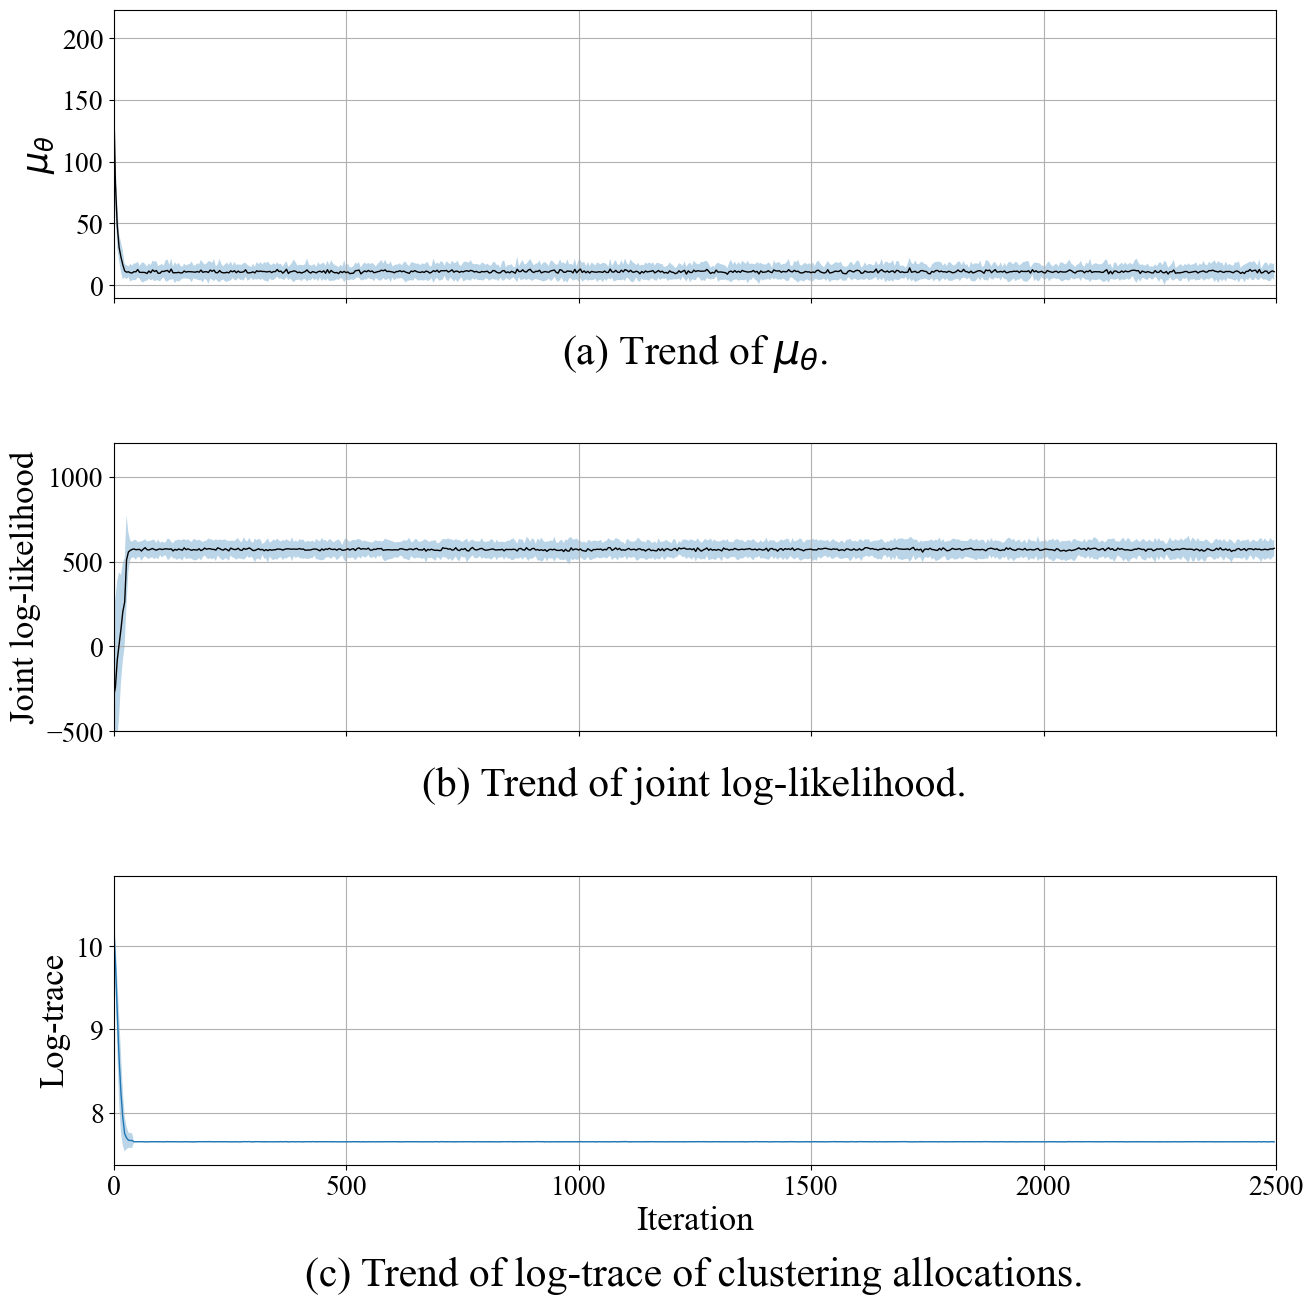

In [5]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

fig, ax = plt.subplots(3,1, sharex=True, sharey=False, figsize=(15,15))
fig.subplots_adjust(hspace=0.5)

x = np.arange(0, 2500, 4)


ax[0].plot(x, mu_mean[x], 'k-', lw=1)
ax[0].fill_between(x, mu_lowci[x], mu_upci[x], alpha=0.3)
ax[0].set_xlim([0,2500])
ax[0].set_ylabel(r'$\mu_{\theta}$', fontsize=25)
ax[0].tick_params(axis="x", labelsize=20)
ax[0].tick_params(axis="y", labelsize=20)
ax[0].set_title(r'(a) Trend of $\mu_{\theta}$.', y=0, pad=-25, verticalalignment="top", fontdict=font)
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[0].grid()

# x_log = np.arange(0,400,1)
ax[1].plot(x, loglikelihood_mean[x], 'k-', lw=1)
ax[1].fill_between(x, loglikelihood_lowci[x], loglikelihood_upci[x], alpha=0.3)
ax[1].set_ylabel('Joint log-likelihood', fontsize=25)
ax[1].set_ylim([-500,1200])
ax[1].set_xlim([0,2500])
ax[1].tick_params(axis="x", labelsize=20)
ax[1].tick_params(axis="y", labelsize=20)
ax[1].set_title(r'(b) Trend of joint log-likelihood.', y=0, pad=-25, verticalalignment="top", fontdict=font)
# ax[1].set_title(r'(b) Density of $\mu_{\theta}$.', fontdict=font)
ax[1].grid()

ax[2].plot(x,log_trace_mean[x], linewidth=1)
ax[2].fill_between(x, log_trace_lowci[x], log_trace_upci[x], alpha=0.3)
ax[2].set_xlabel('Iteration', fontsize=25, fontdict=font)
ax[2].set_ylabel('Log-trace', fontsize=25)
ax[2].tick_params(axis="x", labelsize=20)
ax[2].tick_params(axis="y", labelsize=20)
ax[2].set_xlim([0,2500])
ax[2].set_title(r'(c) Trend of log-trace of clustering allocations.', y=-0.2, pad=-25, verticalalignment="top", fontdict=font)
# ax[2].set_title(r'(b) Density of simulated data.', fontdict=font)
ax[2].grid()

plt.show()
fig.savefig('convergence check-7.png')

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ndong\AppData\Local\Temp\ipykernel_2972\4013259322.py:14: SyntaxWarning: invalid escape sequence '\s'
  ax[0].set_xlabel('$\sigma^2$', fontsize=25)


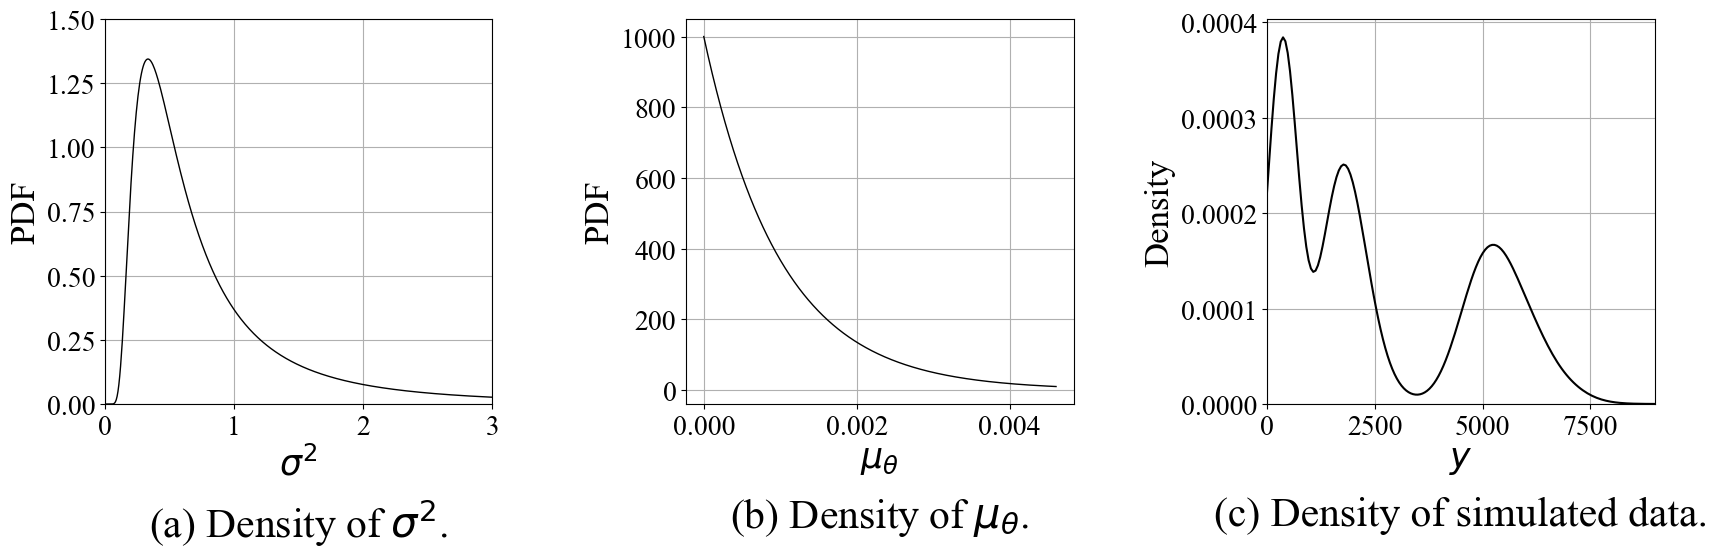

In [43]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

rv = invgamma(a=2, scale=1)
x = np.linspace(0,rv.ppf(0.99), 1000)
pdf = rv.pdf(x)
fig, ax = plt.subplots(1,3, sharex=False, sharey=False, figsize=(20,5))
fig.subplots_adjust(wspace=0.5)

ax[0].plot(x, pdf, 'k-', lw=1, label='frozen pdf')
ax[0].set_xlabel('$\sigma^2$', fontsize=25)
ax[0].set_xlim([0,3])
ax[0].set_ylabel('PDF', fontsize=25)
ax[0].set_ylim([0,1.5])
ax[0].tick_params(axis="x", labelsize=20)
ax[0].tick_params(axis="y", labelsize=20)
ax[0].set_title(r'(a) Density of $\sigma^2$.', y=-0.15, pad=-25, verticalalignment="top", fontdict=font)
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[0].grid()

rv = gamma(a=1, scale=0.001)
x = np.linspace(0,rv.ppf(0.99), 1000)
pdf = rv.pdf(x)


ax[1].plot(x, pdf, 'k-', lw=1, label='frozen pdf')
ax[1].set_xlabel(r'$\mu_{\theta}$', fontsize=25)
ax[1].set_ylabel('PDF', fontsize=25)
ax[1].tick_params(axis="x", labelsize=20)
ax[1].tick_params(axis="y", labelsize=20)
ax[1].set_title(r'(b) Density of $\mu_{\theta}$.', y=-0.15, pad=-25, verticalalignment="top", fontdict=font)
# ax[1].set_title(r'(b) Density of $\mu_{\theta}$.', fontdict=font)
ax[1].grid()

y = DATA['y']

sns.kdeplot(ax=ax[2], data=y,color='black')
ax[2].set_xlabel('$y$', fontsize=25)
ax[2].set_ylabel('Density', fontsize=25)
ax[2].tick_params(axis="x", labelsize=20)
ax[2].tick_params(axis="y", labelsize=20)
ax[2].set_xlim([0,9000])
ax[2].set_title(r'(c) Density of simulated data.', y=-0.15, pad=-25, verticalalignment="top", fontdict=font)
# ax[2].set_title(r'(b) Density of simulated data.', fontdict=font)
ax[2].grid()

plt.show()

In [9]:
SURV_plot = pd.read_csv('FULL_data_with_true_and_pred_surv.csv', index_col=0)
error = abs(SURV_plot['true_surv'] - SURV_plot['pred_surv']).values
# MSE = (sum(error**2)/error.shape[0])**0.5
# MSE
R_sq = 1 - (sum(error**2)/sum((SURV_plot['true_surv'] - SURV_plot['true_surv'].mean()) ** 2))
R_sq = round(R_sq, 4)
R_sq
# MSE = np.median(round(error, 4))
# MSE

np.float64(0.6701)

In [11]:
surv_z1 = SURV_plot[SURV_plot['z_y'] == 1]
error = abs(surv_z1['true_surv'] - surv_z1['pred_surv']).values
R_sq = 1 - (sum(error**2)/sum((surv_z1['true_surv'] - surv_z1['true_surv'].mean()) ** 2))
R_sq_1 = round(R_sq, 4)

In [12]:
surv_z2 = SURV_plot[SURV_plot['z_y'] == 2]
error = abs(surv_z2['true_surv'] - surv_z2['pred_surv']).values
R_sq = 1 - (sum(error**2)/sum((surv_z2['true_surv'] - surv_z2['true_surv'].mean()) ** 2))
R_sq_2 = round(R_sq, 4)

In [13]:
surv_z3 = SURV_plot[SURV_plot['z_y'] == 3]
error = abs(surv_z3['true_surv'] - surv_z3['pred_surv']).values
R_sq = 1 - (sum(error**2)/sum((surv_z3['true_surv'] - surv_z3['true_surv'].mean()) ** 2))
R_sq_3 = round(R_sq, 4)

0.1595
0.0963
0.2203


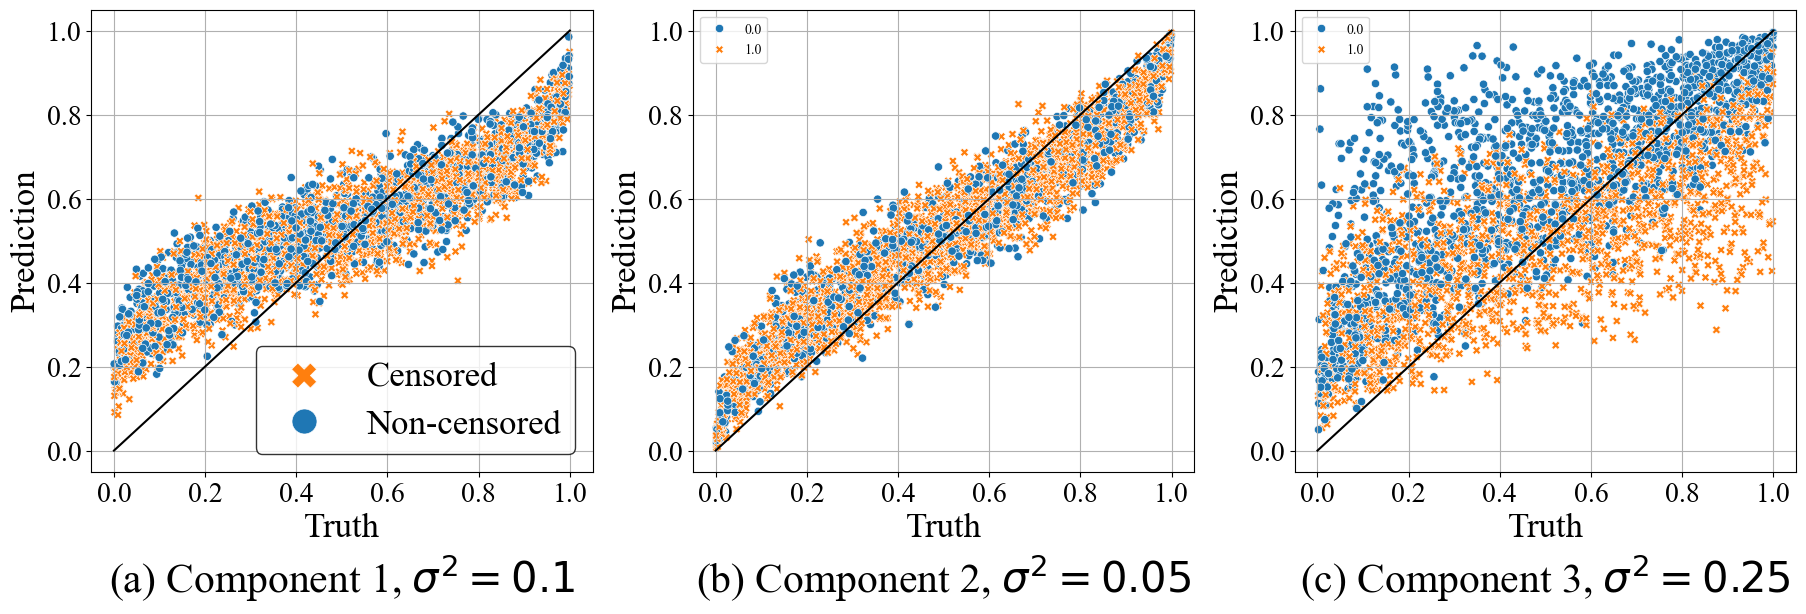

In [26]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

rv = invgamma(a=2, scale=1)
x = np.linspace(0,rv.ppf(0.99), 1000)
pdf = rv.pdf(x)
fig, ax = plt.subplots(1,3, sharex=False, sharey=False, figsize=(22,6))
fig.subplots_adjust(wspace=0.2)
fig.subplots_adjust(hspace=0.4)

sns.scatterplot(SURV_plot[SURV_plot['z_y'] == 1], x='true_surv', y='pred_surv', hue='c_y', style='c_y', ax=ax[0])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[0])
error = abs(SURV_plot[SURV_plot['z_y'] == 1]['true_surv'] - SURV_plot[SURV_plot['z_y'] == 1]['pred_surv'])
MSE = round((sum(error**2)/error.shape[0])**0.5, 4)
# MSE = round(np.median(error), 4)
font_tex = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 25,
        }
ax[0].legend(['Censored', 'Non-censored'], fontsize=25, edgecolor='black', markerscale=3)
ax[0].set_xlabel('Truth', fontsize=25)
ax[0].set_ylabel('Prediction', fontsize=25)
ax[0].tick_params(axis="x", labelsize=20)
ax[0].tick_params(axis="y", labelsize=20)
ax[0].set_title(r'(a) Component 1, $\sigma^2 = 0.1$', y=-0.1, pad=-25, verticalalignment="top", fontdict=font)
ax[0].grid()

print(MSE)

sns.scatterplot(SURV_plot[SURV_plot['z_y'] == 2], x='true_surv', y='pred_surv', hue='c_y', style='c_y', ax=ax[1])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[1])
error = abs(SURV_plot[SURV_plot['z_y'] == 2]['true_surv'] - SURV_plot[SURV_plot['z_y'] == 2]['pred_surv'])
MSE = round((sum(error**2)/error.shape[0])**0.5, 4)
# MSE = round(np.median(error), 4)
font_tex = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 25,
        }

ax[1].set_xlabel('Truth', fontsize=25)
ax[1].set_ylabel('Prediction', fontsize=25)
ax[1].tick_params(axis="x", labelsize=20)
ax[1].tick_params(axis="y", labelsize=20)
ax[1].set_title(r'(b) Component 2, $\sigma^2 = 0.05$', y=-0.1, pad=-25, verticalalignment="top", fontdict=font)
ax[1].grid()
print(MSE)


sns.scatterplot(SURV_plot[SURV_plot['z_y'] == 3], x='true_surv', y='pred_surv', hue='c_y', style='c_y', ax=ax[2])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[2])
error = abs(SURV_plot[SURV_plot['z_y'] == 3]['true_surv'] - SURV_plot[SURV_plot['z_y'] == 3]['pred_surv'])
MSE = round((sum(error**2)/error.shape[0])**0.5, 4)
# MSE = round(np.median(error), 4)
font_tex = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 25,
        }

ax[2].set_xlabel('Truth', fontsize=25)
ax[2].set_ylabel('Prediction', fontsize=25)
ax[2].tick_params(axis="x", labelsize=20)
ax[2].tick_params(axis="y", labelsize=20)
ax[2].set_title(r'(c) Component 3, $\sigma^2 = 0.25$', y=-0.1, pad=-25, verticalalignment="top", fontdict=font)
ax[2].grid()
print(MSE)

plt.show()

In [5]:
sf_unit = pd.read_csv('pred_sf_unit.csv', index_col=0)
sf_unit = sf_unit.iloc[:,0].values
sf_cluster = pd.read_csv('pred_sf_cluster.csv', index_col=0)
sf_cluster = sf_cluster.iloc[:,0].values
FULL = pd.concat(data, ignore_index=True)
true_sf = FULL['true_sf'].values
true_Z = FULL['Z'].values+1
Comp = pd.DataFrame({'True': true_sf, 'Unit': sf_unit, 'Cluster': sf_cluster, 'cluster': true_Z})
for i in range(7):
    Comp.loc[Comp['cluster']==i+1, 'Z'] = f'Cluster {i+1}'

In [6]:
outliers = np.zeros(Comp.shape[0])
outliers[np.arange(0,Comp.shape[0], 100)+99] += 1
Comp['outliers'] = outliers
for i in range(2):
    if i == 0:
        Comp.loc[Comp['outliers'] == i, 'outlier'] = 'No'
    else:
        Comp.loc[Comp['outliers'] == i, 'outlier'] = 'Yes'
Comp.head()

,True,Unit,Cluster,cluster,Z,outliers,outlier
0,0.940173,0.952370,0.948518,1.0,Cluster 1,0.0,No
1,0.864591,0.776567,0.773317,1.0,Cluster 1,0.0,No
2,0.888937,0.859175,0.855192,1.0,Cluster 1,0.0,No
3,0.880548,0.865600,0.866497,1.0,Cluster 1,0.0,No
4,0.907981,0.836521,0.840141,1.0,Cluster 1,0.0,No


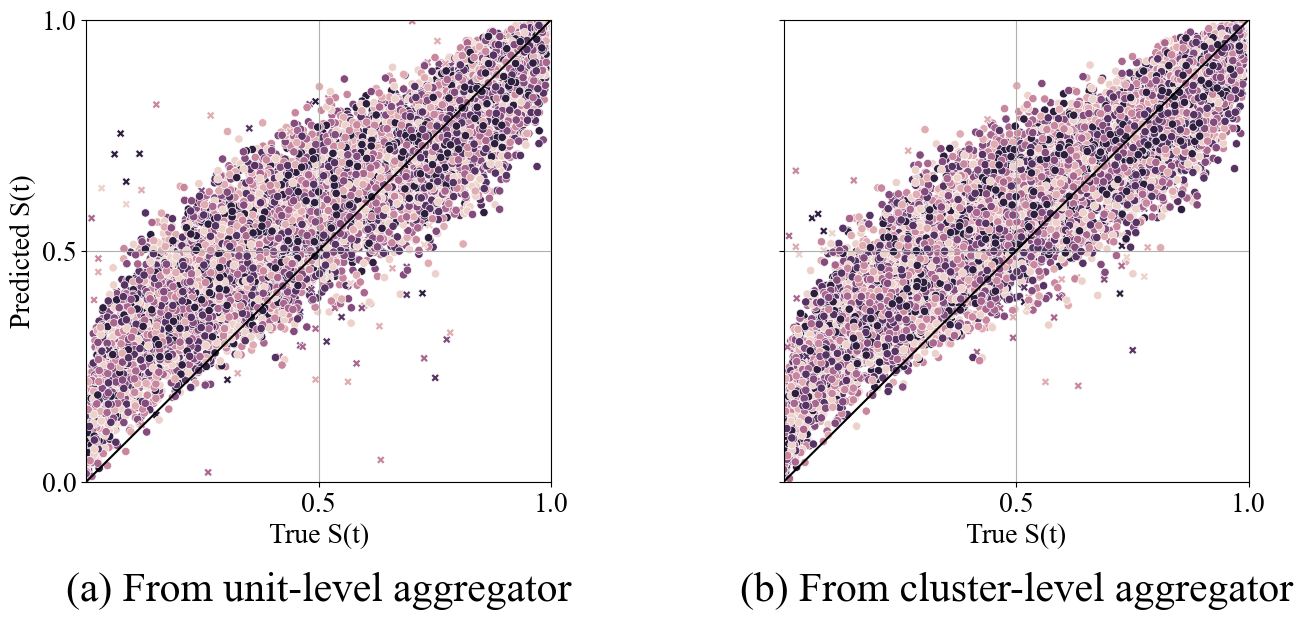

In [7]:
font = {'family': 'Times New Roman',
        'color':  'black',
        'weight': 'normal',
        'size': 30,
        }

title_name = [f'Subset {i+1}' for i in range(20)]
fig, ax = plt.subplots(1,2, sharex=False, sharey=True, figsize=(15,6))
fig.subplots_adjust(wspace=0.5, hspace=0.175)

sns.scatterplot(Comp, x='True', y='Unit', hue='cluster', style='outlier', ax=ax[0])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[0])
ax[0].set_xlabel('True S(t)', fontsize=20)
ax[0].set_xlim([0,1])
ax[0].set_ylabel('Predicted S(t)', fontsize=20)
ax[0].set_ylim([0,1])
ax[0].tick_params(axis="x", labelsize=20)
ax[0].tick_params(axis="y", labelsize=20)
ax[0].set_title('(a) From unit-level aggregator', y=-0.12, pad=-25, verticalalignment="top", fontdict=font)
ax[0].get_legend().remove()
ax[0].set_xticks([0.5,1])
ax[0].set_yticks([0,0.5,1])
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[0].grid()


sns.scatterplot(Comp, x='True', y='Cluster', hue='cluster', style='outlier', ax=ax[1])
sns.lineplot(x=[0,1], y=[0,1], color='black', ax=ax[1])
ax[1].set_xlabel('True S(t)', fontsize=20)
ax[1].set_xlim([0,1])
ax[1].set_ylabel('Predicted S(t)', fontsize=20)
ax[1].set_ylim([0,1])
ax[1].tick_params(axis="x", labelsize=20)
ax[1].tick_params(axis="y", labelsize=20)
ax[1].set_title('(b) From cluster-level aggregator', y=-0.12, pad=-25, verticalalignment="top", fontdict=font)
ax[1].get_legend().remove()
ax[1].set_xticks([0.5,1])
ax[1].set_yticks([0,0.5,1])
# ax[0].set_title(r'(a) Density of $\sigma^2$.', fontdict=font)
ax[1].grid()


fig.add_subplot(111, frameon=False)
plt.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
# plt.xlabel("True Survival Probability", fontsize=40, y=-6, labelpad=80, verticalalignment="top", fontdict=font)
# plt.ylabel("Predicted Survival Probability", fontsize=40, x=-5, labelpad=80, verticalalignment="top", fontdict=font)
plt.show()
fig.savefig('dongS11.jpg', bbox_inches = 'tight')